In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img_t = cv.imread('template.jpg', 0)
img = cv.imread('lemons.jpg', 0)

In [3]:
# plt.figure(figsize=(8,8))
# plt.imshow(img_t, 'gray')
# plt.title('Lemon')
# plt.xticks([])
# plt.yticks([]);

In [4]:
img_fourier_t = np.fft.fft2(img_t)
img_fourier_shift_t = np.fft.fftshift(img_fourier_t)
magnitude_spectrum_t = 20*np.log(np.abs(img_fourier_shift_t))

In [5]:
# plt.figure(figsize=(8,8))
# plt.imshow(magnitude_spectrum_t, cmap = 'gray')
# plt.title('Fourier transform magnitude')
# plt.xticks([])
# plt.yticks([]);

In [6]:
# plt.figure(figsize=(8,8))
# plt.imshow(img, 'gray')
# plt.title('Lemon')
# plt.xticks([])
# plt.yticks([]);

In [7]:
img_zm = img.astype(np.float32) - np.mean(img)
img_fourier = np.fft.fft2(img_zm)
img_fourier_shifted = np.fft.fftshift(img_fourier)
img_spectrum_magnitude = 20 * np.log(np.abs(img_fourier_shifted))

C:\Users\jazoe\AppData\Local\Temp\ipykernel_44888\1187684308.py:4: RuntimeWarning: divide by zero encountered in log
  img_spectrum_magnitude = 20 * np.log(np.abs(img_fourier_shifted))


In [8]:
# plt.figure(figsize=(8,8))
# plt.imshow(img_spectrum_magnitude, cmap = 'gray')
# plt.title('Fourier transform magnitude')
# plt.xticks([])
# plt.yticks([]);

In [9]:
h, w = img_t.shape
img_t_resized = np.zeros(img.shape, dtype=np.float32)
img_t_resized[:h,:w] = img_t
print(img_t.shape)

(2271, 2020)


In [10]:
# plt.figure(figsize=(8,8))
# plt.imshow(img_t_resized)

In [11]:
img_t_resized_fourier = np.fft.fft2(img_t_resized)
img_t_resized_fourier_shifted = np.fft.fftshift(img_t_resized_fourier)
img_t_resized_spectrum_magnitude = 20 * np.log(np.abs(img_t_resized_fourier_shifted))

In [12]:
# plt.figure(figsize=(8,8))
# plt.imshow(img_t_resized_spectrum_magnitude, cmap = 'gray')
# plt.title('Fourier transform magnitude')
# plt.xticks([])
# plt.yticks([]);

In [13]:
cc_img_fourier = img_fourier * np.conj(img_t_resized_fourier)

In [14]:
cc_img = np.fft.ifft2(cc_img_fourier)
corr = np.real(cc_img)

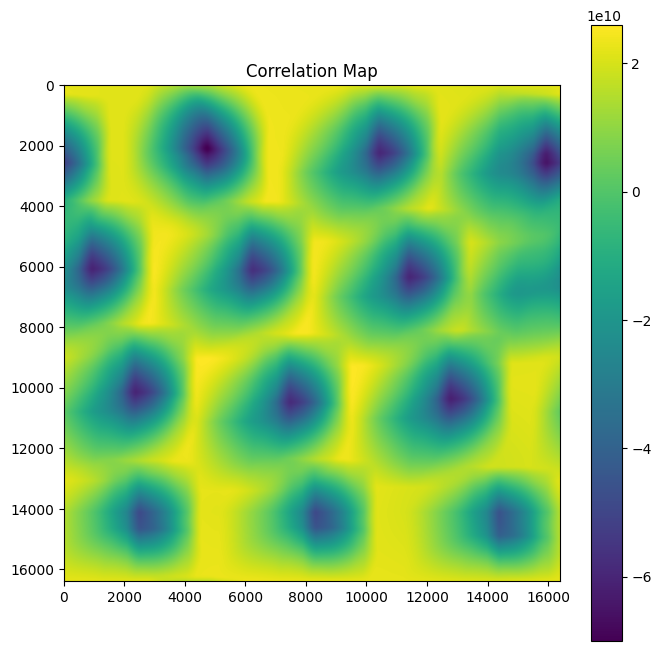

In [15]:
plt.figure(figsize=(8,8))
plt.imshow(corr, cmap='viridis')
plt.colorbar()
plt.title("Correlation Map")
plt.show()

In [16]:
from skimage.feature import peak_local_max
inverted_corr = -corr
peaks = peak_local_max(inverted_corr, min_distance=10, threshold_rel=0.5)

In [17]:
len(peaks)

12

In [18]:
from matplotlib.patches import Rectangle

def draw_template_boxes(image, peaks, template_shape, figsize=(10,10), linewidth=2, color='r', save_path=None):
    img = image.copy()

    # normalize to float [0,1] for display if needed
    if img.dtype != np.float32 and img.dtype != np.float64:
        img = img.astype(np.float32)
        if img.max() > 1.0:
            img /= 255.0

    is_gray = (img.ndim == 2)
    h_t, w_t = template_shape

    fig, ax = plt.subplots(figsize=figsize)
    if is_gray:
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    else:
        ax.imshow(img, vmin=0, vmax=1)

    peaks_arr = np.array(peaks).reshape(-1, 2)  # (N,2) as (row, col)
    H, W = img.shape[:2]

    for (y, x) in peaks_arr:
        x0 = int(round(x))
        y0 = int(round(y))
        # clip top-left so it stays inside image
        x0 = max(0, min(x0, W-1))
        y0 = max(0, min(y0, H-1))

        # clip width/height so the rectangle doesn't exceed image bounds
        w_clip = min(w_t, W - x0)
        h_clip = min(h_t, H - y0)

        rect = Rectangle((x0, y0), w_clip, h_clip, linewidth=linewidth, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

    ax.set_axis_off()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.show()

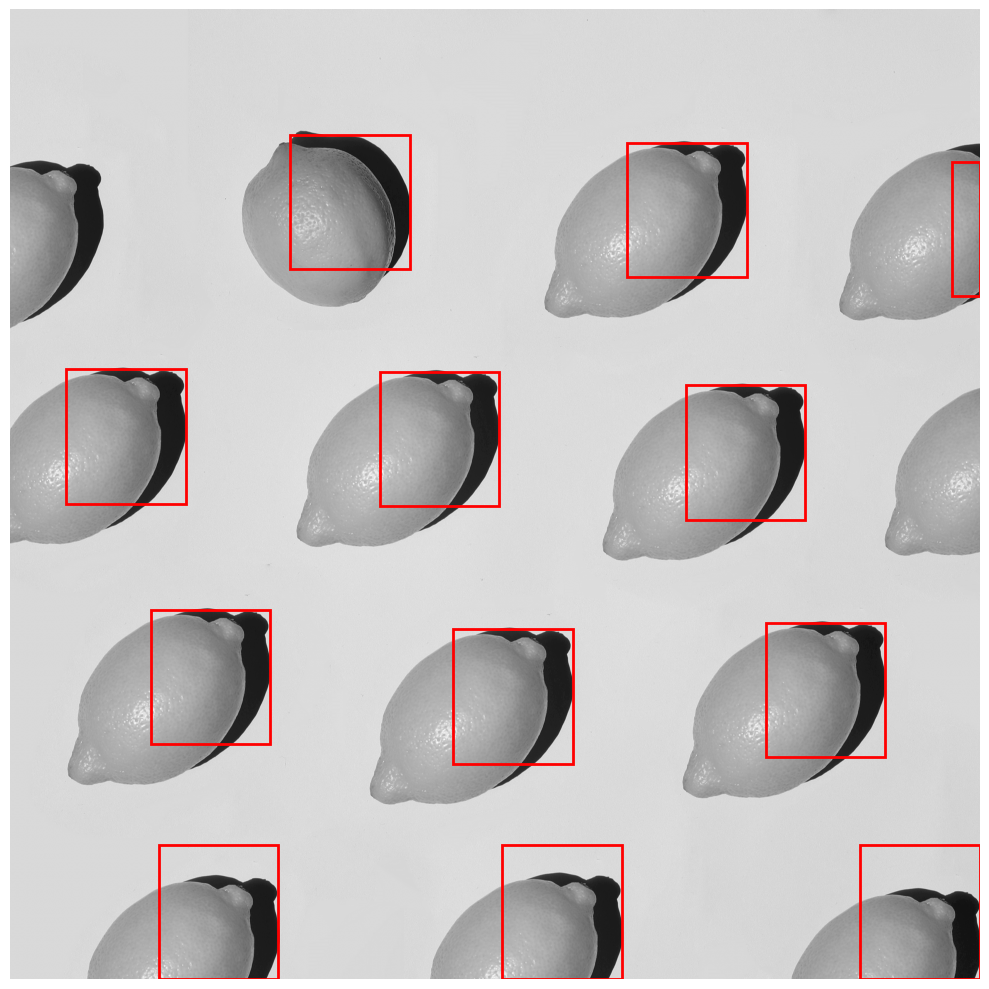

In [19]:
draw_template_boxes(img, peaks, template_shape=img_t.shape)